In [20]:
import numpy as np  
import gpflow
import matplotlib.pyplot as plt 

import sys
sys.path.append("..")
from atmodel import AdaptiveTransferGPR, ConditionalMOGP
from atkernel import TransferKernel, TransferCoregion
from atlikelihood import TransferLikelihood

np.random.seed(123)

## Demonstration of transfer coregionalization
Right, so before we start, I am using "transfer" to indicate that the training procedure is conditional. 
The AT-GP or "adaptive transfer model/GP" is the one in Cao.
With "coregionalization GP"/ICM I mean the one found in GPFlow by default, which is the one described in Bonilla's paper.

The difference between the "adaptive transfer model" and the "transfer coregionalization model" is that in the adaptive transfer model, the weight matrix is $$B = \begin{bmatrix} 1 & \lambda \\ \lambda & 1 \end{bmatrix},$$
while in the ICM it's
$$W = \begin{bmatrix} a & b \\ c & d \end{bmatrix}, B = WW^{T} + \begin{bmatrix} \kappa & 1 \\ 1 & \kappa \end{bmatrix}$$
So $\kappa$ scales the variance in this, while $\lambda$ in the transfer kernel scales the covariance/captures the correlation between the source and target tasks. The nice thing about the ICM implementation is that everything is nice and PSD.

In [21]:
def plot_gp(x, mu, var, color, label):
    plt.plot(x, mu, color=color, lw=2, label=label)
    plt.fill_between(
        x[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color=color,
        alpha=0.4,
    )


def plot(m):
    plt.figure(figsize=(16, 4))
    Xtest = np.linspace(0, 100, 100)[:, None]
    (line,) = plt.plot(X1, Y1, "x", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.zeros_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y1")
    (line,) = plt.plot(X2_full, Y2_full, "x", mew=2, alpha=0.5, color="orange")
    (line,) = plt.plot(X2, Y2, "x", mew=2, color="black")
    mu, var = m.predict_f(np.hstack((Xtest, np.ones_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y2")

    plt.legend()


def plot_gpr(m):
    plt.figure(figsize=(16, 4))
    Xtest = np.linspace(0, 100, 100)[:, None]
    (line,) = plt.plot(X1, Y1, "x", mew=2, label="source data")
    mu, var = m.predict_f(Xtest)
    (line,) = plt.plot(X2_full, Y2_full, "x", mew=2, alpha=0.5, color="orange", label="all target data")
    (line,) = plt.plot(X2, Y2, "x", mew=2, color="black", label ="available target data")
    plot_gp(Xtest, mu, var, line.get_color(), "Y2")

    plt.legend()

We generate a sine wave and a version we shift by 2 units, then use 10% of that data to fit and predict.

Text(0.5, 0, 'y')

<Figure size 800x400 with 0 Axes>

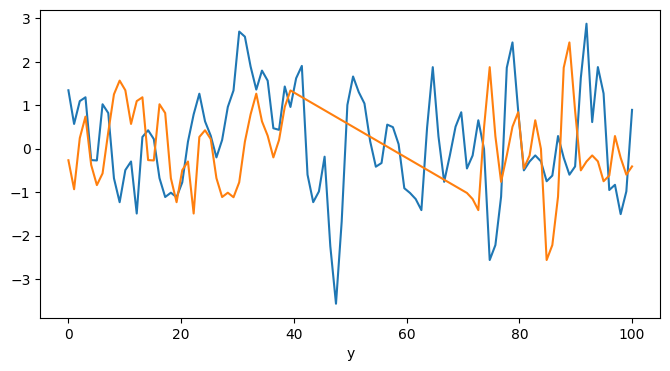

In [22]:

X1 = np.linspace(0, 100, 100)[:,None]  # Observed locations for first output
X2_full = np.linspace(0, 100, 100)[:,None]  # Observed locations for second output

Xall = np.linspace(0, 110, 110).reshape(-1, 1)
k = gpflow.kernels.RBF(active_dims=[0])
Yall  = np.random.multivariate_normal(np.zeros_like(Xall[:,0]), k(Xall))
Y1 = Yall[10:110][:,None]
Y2_full = Yall[0:100][:,None]
# Y1 = np.sin(6 * X1) + np.random.randn(*X1.shape) * 0.03
# Y2 = np.sin(6 * X2 + 0.7) + np.random.randn(*X2.shape) * 0.1

ind = np.concatenate((np.arange(40), np.arange(70, 100)))
plt.figure(figsize=(8, 4))
X2 = X2_full[ind]
Y2 = Y2_full[ind]
plt.figure(figsize=(8, 4))
plt.plot(X1, Y1, mew=2)
plt.plot(X2, Y2,  mew=2)
plt.xlabel("X")
plt.xlabel("y")

In [23]:
# # make a dataset with two outputs, correlated, heavy-tail noise. One has more noise than the other.
# X1 = np.linspace(0, 100, 100)[:,None]  # Observed locations for first output
# X2_full = np.linspace(0, 100, 100)[:,None]  # Observed locations for second output

# Y1 = np.sin(6 * X1) + np.random.randn(*X1.shape) * 0.15
# Y2_full = np.sin(6 * X2_full + 2) + np.random.randn(*X2_full.shape) * 0.15
# #ind = np.random.choice(np.arange(100), 10)
# ind = np.concatenate((np.arange(40), np.arange(70, 100)))
# plt.figure(figsize=(8, 4))
# X2 = X2_full[ind]
# Y2 = Y2_full[ind]


# #Ytest = np.sin(6 * Xtest + 0.1) + np.random.randn(*Xtest.shape) * 0.15
# plt.plot(X1, Y1, "x", mew=2, label="source data")
# plt.plot(X2_full, Y2_full, "x", mew=2, color="orange", label="all target data")
# plt.plot(X2, Y2, "x", mew=2, color="black", label="available target data")
# plt.xlabel("x")
# plt.xlabel("y")
# plt.title("Interpolation task data")
# #plt.plot(Xtest, Ytest, "x", mew=2)
# plt.legend()
# plt.show()


In [24]:
from scipy.stats import pearsonr
print("Output correlation is about", pearsonr(Y2_full, Y1))

Output correlation is about PearsonRResult(statistic=array([-0.0993614]), pvalue=array([0.3253327]))


### Adaptive Transfer model

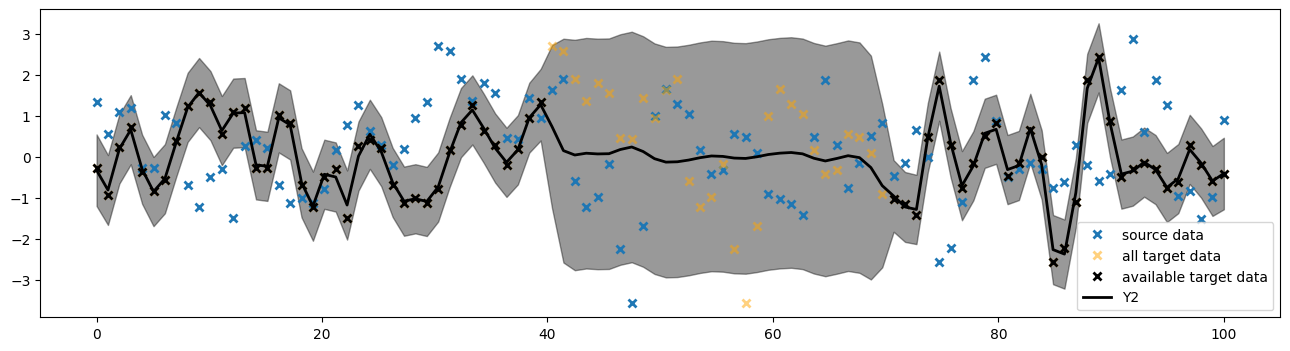

      message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
      success: True
       status: 0
          fun: 81.9375627499333
            x: [-1.974e-01  7.408e-01  1.724e+00  1.872e+00 -2.251e+00]
          nit: 17
          jac: [ 1.728e-02  3.784e-02 -4.126e-02 -7.446e-04 -2.103e-02]
         nfev: 34
         njev: 34
     hess_inv: <5x5 LbfgsInvHessProduct with dtype=float64>
 loss_history: [86.04150768979615, 84.35626101485497, 82.53861073400883, 82.26068561115243, 82.00576411498265, 81.95221818829933, 81.94233578198708, 81.94190127321552, 81.94168290082953, 81.94156186236962, 81.94105783294292, 81.94085780729529, 81.94047706567181, 81.9396513434768, 81.93856128020148, 81.93756274994169, 81.9375627499333]


In [25]:
# Interpolation with AT-GP
at_gpr = AdaptiveTransferGPR(data_source=(X1, Y1), 
                            data_target=(X2, Y2), 
                            kernel=TransferKernel(
                                lmb=0.1, 
                                kernel=gpflow.kernels.RBF(), 
                                source_length=len(X1)), 
                            )

res = gpflow.optimizers.Scipy().minimize(
    at_gpr.training_loss,
    at_gpr.trainable_variables,
    method="L-BFGS-B",
    track_loss_history=True
)

plot_gpr(at_gpr)
plt.show()
print(res)

This training procedure is extremely unstable, and while we do get a somewhat decent mean interpolation in low-data areas, the variance is a bit wonky. In the following cell, we can examine the model and see that the two tasks have a negative correlation.

In [26]:
at_gpr

name,class,transform,prior,trainable,shape,dtype,value
AdaptiveTransferGPR.kernel.lmb,Parameter,SoftClip,,True,(),float64,-0.118854
AdaptiveTransferGPR.kernel.kernel.variance,Parameter,Softplus,,True,(),float64,1.88798
AdaptiveTransferGPR.kernel.kernel.lengthscales,Parameter,Softplus,,True,(),float64,1.13062
AdaptiveTransferGPR.likelihood.source.variance AdaptiveTransferGPR.likelihood.likelihoods[0].variance,Parameter,Softplus + Shift,,True,(),float64,2.01486
AdaptiveTransferGPR.likelihood.target.variance AdaptiveTransferGPR.likelihood.likelihoods[1].variance,Parameter,Softplus + Shift,,True,(),float64,0.100113


### ICM

The ICM needs tasks indices. In the transfer model, we assume the source and target task to be ordered. We should probably think about whether that's smart. 

In [27]:
# Augment the input with ones or zeros to indicate the required output dimension
X_augmented = np.vstack(
    (np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2))))
)

# Augment the Y data with ones or zeros that specify a likelihood from the list of likelihoods
Y_augmented = np.vstack(
    (np.hstack((Y1, np.zeros_like(Y1))), np.hstack((Y2, np.ones_like(Y2))))
)

In [28]:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpflow.kernels.RBF(active_dims=[0])

# Coregion kernel
coreg = gpflow.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg
#kern2 = TransferKernel(0.5, gpflow.kernels.RBF(), source_length=int(len(Y_augmented) - np.sum(Y_augmented[:,1])))

# This likelihood switches between Gaussian noise with different variances for each f_i:
lik = TransferLikelihood(source=gpflow.likelihoods.Gaussian(), target=gpflow.likelihoods.Gaussian())
# now build the GP model as normal

m = gpflow.models.VGP((X_augmented, Y_augmented), kernel=kern, likelihood=lik)

# fit the covariance function parameters
res = gpflow.optimizers.Scipy().minimize(
    m.training_loss,
    m.trainable_variables,
    method="L-BFGS-B",
    track_loss_history=True
)

Training is via a VGP because the likelihood is custom - in this case, it's Gaussian and you can swap it out for the TransferLikelihood and train a GPR instead, as well. Thus far I haven't seen the coregionalization model fit very well, and when it does it virtually ignores the available target data. 

Text(0.5, 1.0, 'Multitask GP')

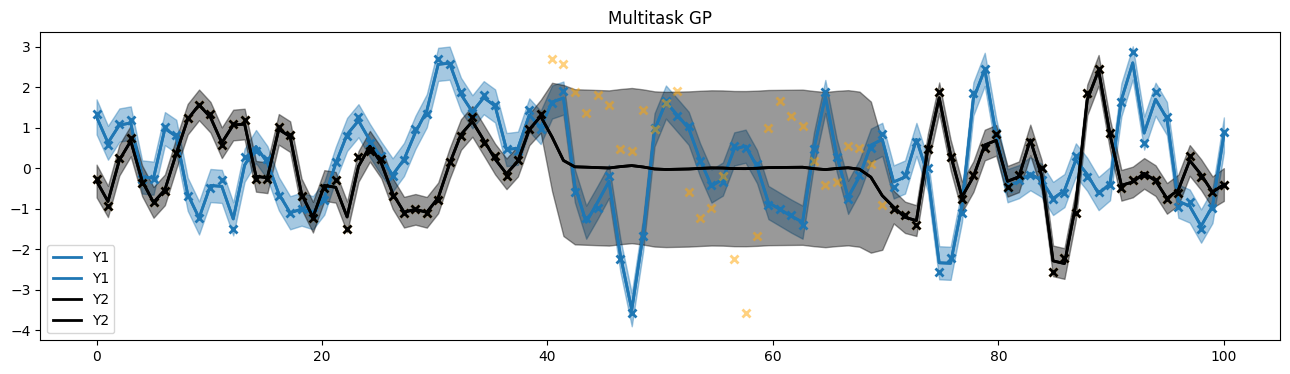

In [29]:
plot(m)
plt.title("Multitask GP")

In [30]:
m.kernel.kernels[1].output_covariance()

<tf.Tensor: shape=(2, 2), dtype=float64, numpy=
array([[ 1.42306378, -0.02664838],
       [-0.02664838,  0.91440621]])>

### Combining the two
Now, I want to know whether the conditioning makes the difference, *and* whether training is more stable if we do not constrain the weights of the adaptive transfer kernel. We have a working implementation of the AT-GP, so I just adapted the weights to work like they do in the coregionalization model. This should ensure they are PSD, and give us some room to play around with constraining the weights in different ways. 

I implemented the transfer kernel in such a way that the weights now mimic those of the coregion kernel. I can still use the weights from Caos paper if I want to (use_lmb = True), but now I can compare a conditional ICM and a stable transfer GP.

In [31]:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpflow.kernels.RBF(active_dims=[0])

# Coregion kernel
coreg = gpflow.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg

X_aug = np.concatenate((np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2)))))
Y_aug = np.concatenate((np.hstack((Y1, np.zeros_like(Y1))), np.hstack((Y2, np.ones_like(Y2)))))

      message: ABNORMAL: 
      success: False
       status: 2
          fun: 81.93978886160363
            x: [-8.684e-02 -8.516e-01 -3.169e-01  5.286e-01  1.025e+01
                 5.191e-01  1.254e+00  1.025e+01  7.395e-01  1.716e+00
                 7.189e-01 -2.251e+00]
          nit: 10
          jac: [-9.101e-03  1.518e-02 -2.494e-03 -2.446e-02  0.000e+00
                -2.595e-02 -0.000e+00  0.000e+00 -1.980e-02 -8.047e-03
                -4.925e-03 -1.097e-03]
         nfev: 50
         njev: 50
     hess_inv: <12x12 LbfgsInvHessProduct with dtype=float64>
 loss_history: [87.07736372858506, 85.95899057991784, 82.95071527143915, 82.50134115394428, 82.10693925511247, 81.99838562064195, 81.98589129485869, 81.95026909545453, 81.9413942777507, 81.93978886160363]
╒════════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═══════════════════════════════╕
│ name                                                

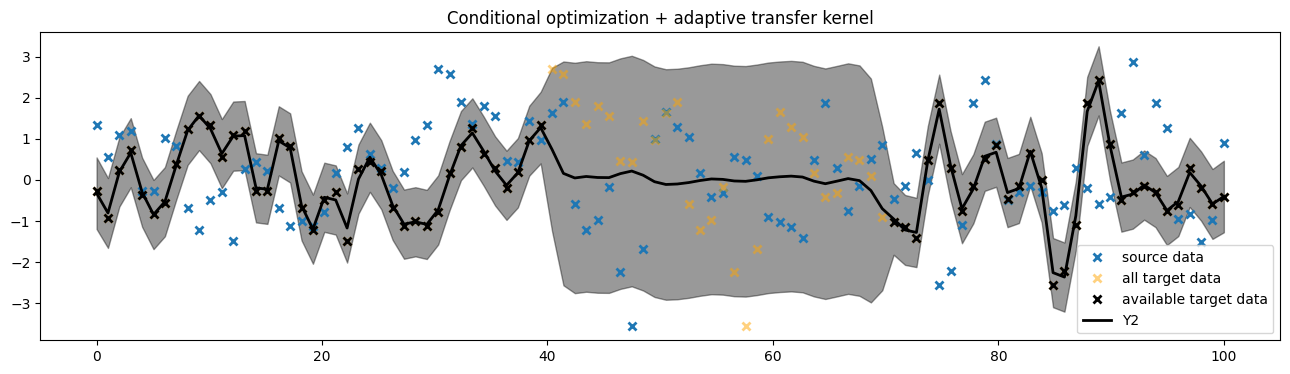

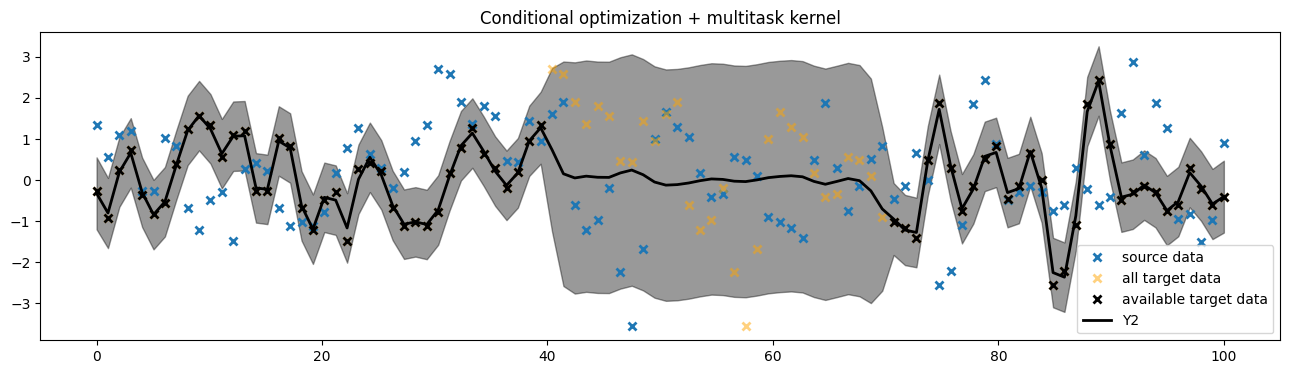

In [32]:
# Interpolation with AT-GP
stable_transfer = AdaptiveTransferGPR(data_source=(X1, Y1), 
                            data_target=(X2, Y2), 
                            kernel=TransferCoregion(
                                lmb=0.5, 
                                kernel=gpflow.kernels.RBF(), 
                                source_length=len(X1), use_lmb=True), 
                            )

res = gpflow.optimizers.Scipy().minimize(
    stable_transfer.training_loss,
    stable_transfer.trainable_variables,
    method="L-BFGS-B",
    track_loss_history=True
)

plot_gpr(stable_transfer)
plt.title("Conditional optimization + adaptive transfer kernel")

print(res)

# Unconstrained weights
unconstrained_transfer = AdaptiveTransferGPR(data_source=(X1, Y1), 
                            data_target=(X2, Y2), 
                            kernel=TransferCoregion(
                                lmb=0.5, 
                                kernel=gpflow.kernels.RBF(), 
                                source_length=len(X1), use_lmb=False), 
                            )

res = gpflow.optimizers.Scipy().minimize(
    unconstrained_transfer.training_loss,
    unconstrained_transfer.trainable_variables,
    method="L-BFGS-B",
    track_loss_history=True
)

plot_gpr(unconstrained_transfer)
plt.title("Conditional optimization + multitask kernel")

gpflow.utilities.print_summary(unconstrained_transfer)
gpflow.utilities.print_summary(stable_transfer)

Now we have smooth predictions with a somewhat reasonable mean and reasonable uncertainties, and the training is actually quite stable because we do not constrain the weight matrix, *and* we have the nice PSD property of the coregion model. Let's take a look at the weight matrix:

In [18]:
print(stable_transfer.kernel.get_B())
print(unconstrained_transfer.kernel.get_B())

tf.Tensor(
[[0.44787318 0.20719969]
 [0.28099448 0.71470526]], shape=(2, 2), dtype=float64)
tf.Tensor(
[[2.76396424 0.20693876]
 [0.20693876 1.07271761]], shape=(2, 2), dtype=float64)


### Quantifying performance

Thus far, we just evaluated things based on "do I like the look of this prediction", so time for some quantification:

In [19]:
from sklearn.metrics import mean_squared_error
X2_filt = X2_full[[i for i in np.arange(100) if i not in ind]]
Y2_filt = Y2_full[[i for i in np.arange(100) if i not in ind]]

for i, model in enumerate([at_gpr, stable_transfer, unconstrained_transfer, m]):
    if i == 3:
        X2_filt = np.hstack((X2_filt, np.ones_like(X2_filt)))
        Y2_filt = np.hstack((Y2_filt, np.ones_like(Y2_filt)))
    Yhat, Yvar = model.predict_f(X2_filt)
    print(mean_squared_error(Yhat, Y2_filt))

1.606276446588004
1.606418733834829
1.6063291228909173
1.369613666588843


Apparently, training instability leads to a 0.06 performance increase... It is reasonably safe to conclude that conditional training can pay off. 